## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [3]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [4]:
# import libraries for data manipulation
import pandas as pd
import numpy as np

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# import libraries for splitting train and test data
from sklearn.model_selection import train_test_split

# To build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To compute classification metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [5]:
# Code to read the data from csv file
df = pd.read_csv('Loan_Modelling.csv')

## Data Overview

* Observations
* Sanity checks

In [6]:
# Copying data to another variable to avoid any changes to original data
data = df.copy()

In [7]:
# Code to view the first 5 rows
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [8]:
#  Code to view the last 5 rows
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [9]:
# Code to get the shape of the data
data.shape

(5000, 14)

Observations:There are 5000 rows and 14 columns in dataset.


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


Observations:

As per the data info there are 5000 rows and 14 columns.

There are 13 columns of Int data type and 1 Float type.

In [11]:
# checking missing values across each columns
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


Observations:There are no missing values in any columns of the data.




In [12]:
# Checking for duplicate values
data.duplicated().sum()

np.int64(0)

Observation: There are no duplicates value in dataset.


In [13]:
# Cheching the ID columns values
data.ID.nunique()

5000

Observation : We can drop the ID column as there is only unique values of ID.

In [14]:
## Converting the data type of categorical features to 'category'
cat_cols = [
"Education",
"Personal_Loan",
"Securities_Account",
"CD_Account",
"Online",
"CreditCard",
]
data[cat_cols] = data[cat_cols].astype("category")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   ID                  5000 non-null   int64   
 1   Age                 5000 non-null   int64   
 2   Experience          5000 non-null   int64   
 3   Income              5000 non-null   int64   
 4   ZIPCode             5000 non-null   int64   
 5   Family              5000 non-null   int64   
 6   CCAvg               5000 non-null   float64 
 7   Education           5000 non-null   category
 8   Mortgage            5000 non-null   int64   
 9   Personal_Loan       5000 non-null   category
 10  Securities_Account  5000 non-null   category
 11  CD_Account          5000 non-null   category
 12  Online              5000 non-null   category
 13  CreditCard          5000 non-null   category
dtypes: category(6), float64(1), int64(7)
memory usage: 342.7 KB


In [15]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0


Observations:

ID column can be removed as this does not provide any prediction/mapping for future loan customers.

Average Age of customer is 45 and the customers age range from min 23 to 67.

There is an Negative Experience of -3 present in data it could be data error , Average Experience of customer 20 and max is 43.

Average income of customers is 73k Dollars , there is a huge diffference in 75th % and max value of income.

Some customers have CCAvg spending of 0 Dollars a month, there is a huge diffference in 75th % and max value of income.

Average Mortgages of customers is 56k dollars and many customers do not have any mortgages.

In [16]:
# Drop ID Column and save it to new dataframe
newdataFrame = data.drop(["ID"], axis=1)

Observation : Drop the ID column and saved to newdataframe.

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

**Question 1 : What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?**

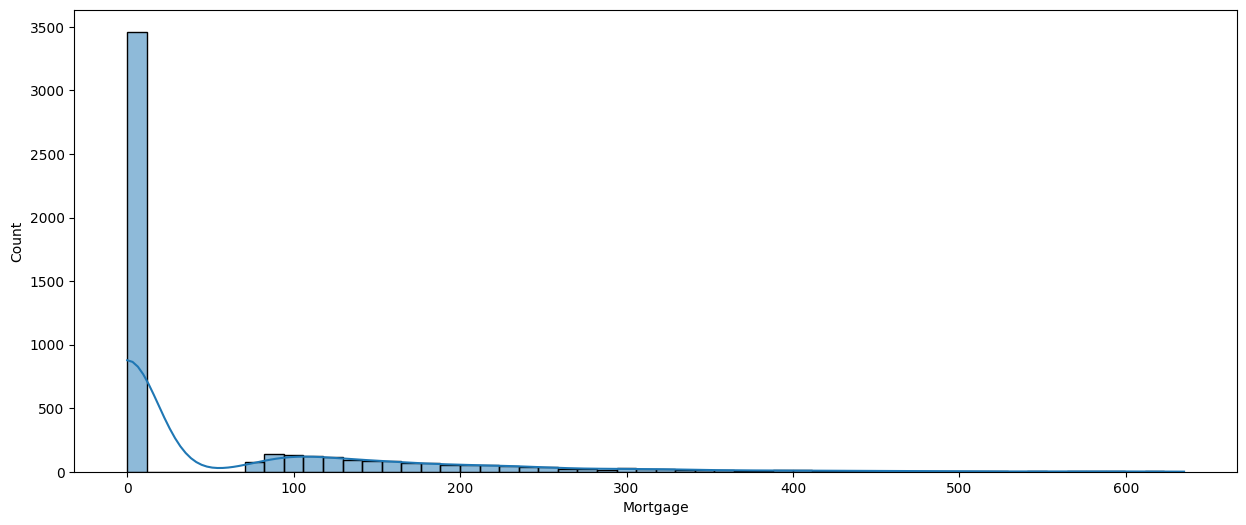

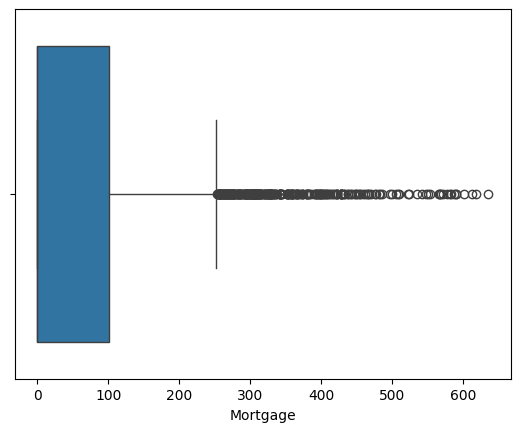

In [17]:
# Create a histogram for evaluting distribution of 'Mortgage' column
plt.figure(figsize=(15,6))
sns.histplot(data = newdataFrame, x="Mortgage", kde=True)
plt.show()

# Create a Boxplot for the Mortgage Column
sns.boxplot(data = newdataFrame, x="Mortgage")
plt.show()

Observation :
As per the graphs most of the people do not have Mortage and distribution is right-skewed and there are outliers.

**Question 2 : How many customers have credit cards?**

In [18]:
#Count the customers who have using 'CreditCard' column
newdataFrame['CreditCard'].value_counts()

,count
CreditCard,
0,3530
1,1470


Observation : There are 1470 customers that own a credit card.

**Question 3 : What are the attributes that have a strong correlation with the target attribute (personal loan)?**

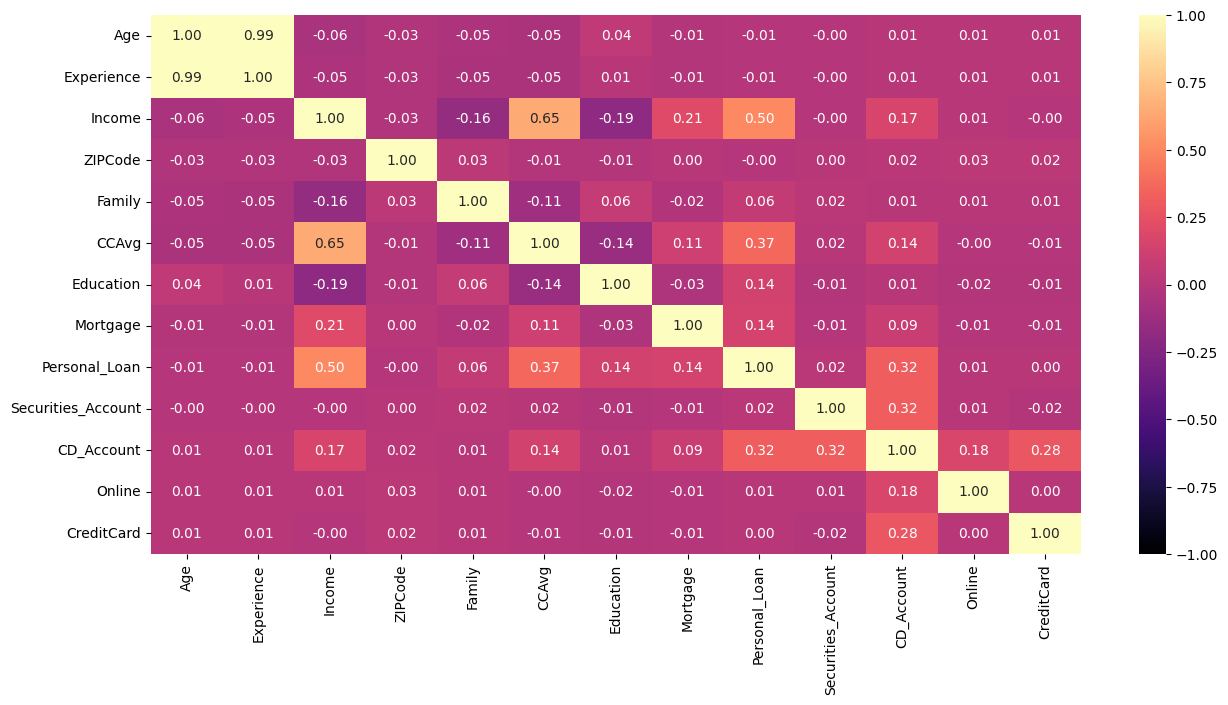

In [19]:
# Created the heatmap graph to get correlation between all attribute
plt.figure(figsize=(15, 7))
sns.heatmap(newdataFrame.corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="magma");
plt.show()

Observation :
Attributes that have strong correlation with the target attributes personal loan is : Income, CCAvg and CD_Account.

Age and Experience columns have a perfect correlation almost to 1 (i.e. 0.99).

**Question 4 : How does a customer's interest in purchasing a loan vary with their age?**

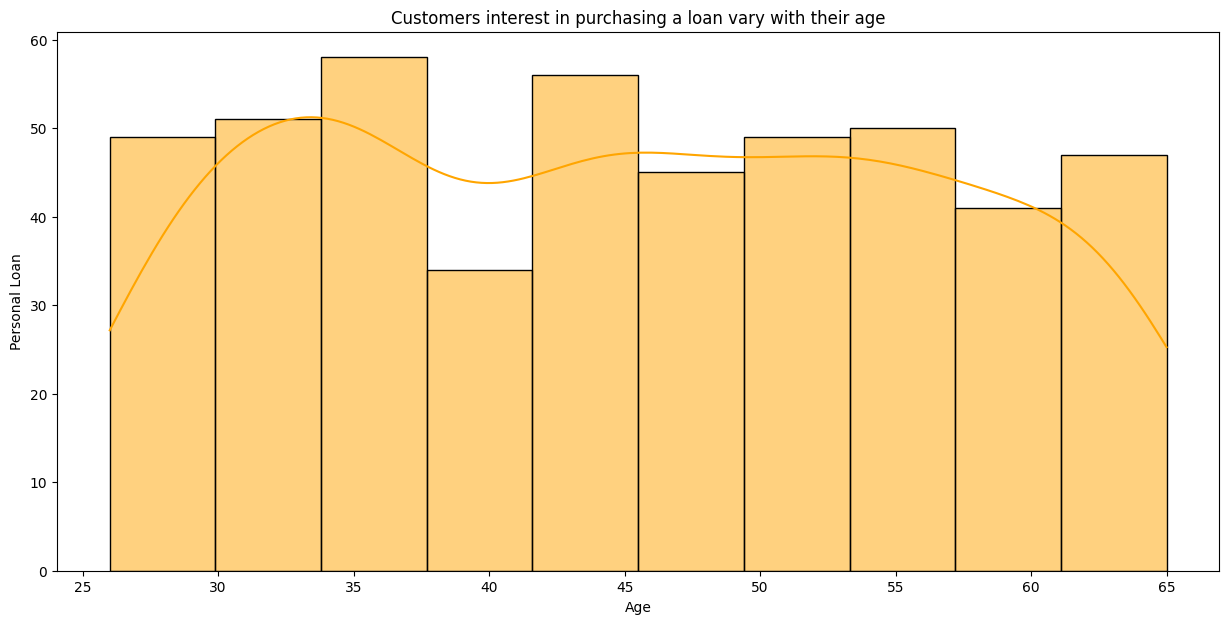

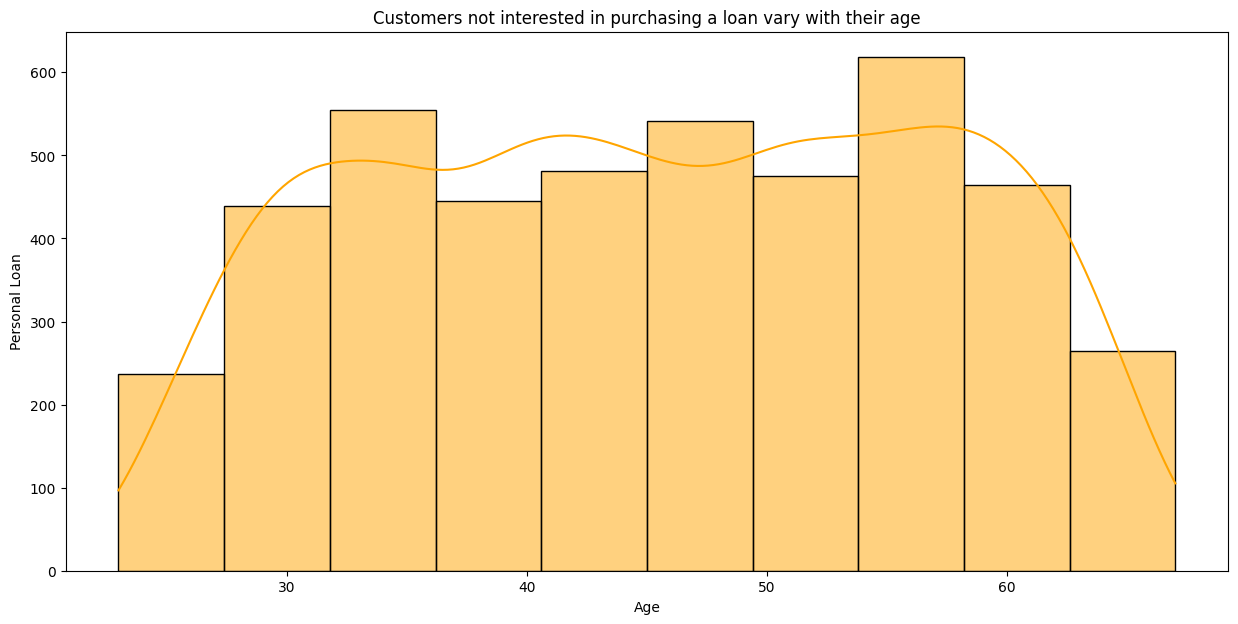

In [20]:
# Get all customers interested in purchasing a loan
customer_accepted_loan = newdataFrame[newdataFrame['Personal_Loan']== 1]

# Create the histogram for Age of customers interested in purchasing a loan
plt.figure(figsize=(15, 7))
sns.histplot(customer_accepted_loan['Age'], kde=True, bins=10, color='orange')
plt.title("Customers interest in purchasing a loan vary with their age")
plt.xlabel('Age')
plt.ylabel('Personal Loan')
plt.show()

# Get all customers not interested in purchasing a loan
customer_not_accepted_loan = newdataFrame[newdataFrame['Personal_Loan']== 0]

# Create the histogram for Age of customers not interested in purchasing a loan
plt.figure(figsize=(15, 7))
sns.histplot(customer_not_accepted_loan['Age'], kde=True, bins=10, color='orange')
plt.title("Customers not interested in purchasing a loan vary with their age")
plt.xlabel('Age')
plt.ylabel('Personal Loan')
plt.show()

Observation : Customer with age 45 years and below are taking more personal loan and the customers above 45 year are taking less personal loan.

Question 5 : How does a customer's interest in purchasing a loan vary with their education?

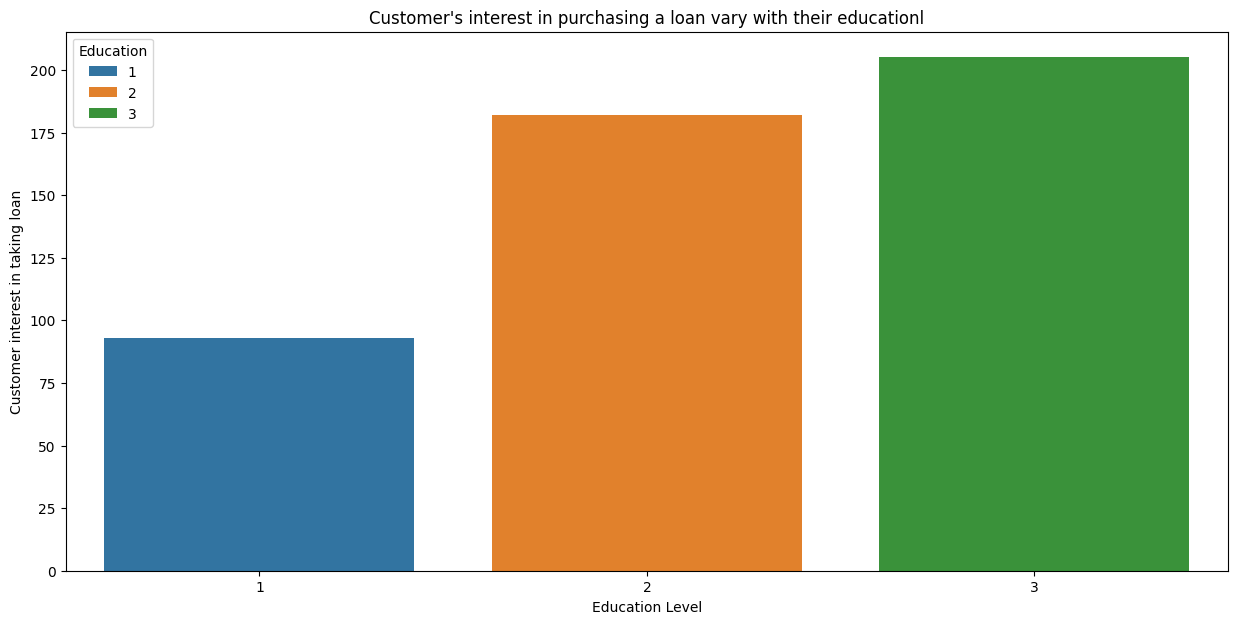

In [21]:
# Get all customers interested in purchasing a loan
customer_accepted_loan = newdataFrame[newdataFrame['Personal_Loan'] == 1]

# Create the graph to visualize the interest in purchasing a loan for all education levels
plt.figure(figsize=(15, 7))
sns.countplot(x='Education', data=customer_accepted_loan, hue='Education')
plt.title("Customer's interest in purchasing a loan vary with their educationl")
plt.xlabel('Education Level')
plt.ylabel('Customer interest in taking loan')
plt.show()

Observation :
Customers with Advanced/Professional education level (i.e. 3) are taking more loans.

Customers with Undergraduate level (i.e. 1) are taking less loans.


**Univariate analysis**

In [22]:
# Analysing Experience column : there are some negative values for this it colud be data input errors.
newdataFrame[newdataFrame["Experience"] < 0]["Experience"].unique()


array([-1, -2, -3])

In [23]:
data["Experience"].describe()

,Experience
count,5000.000000
mean,20.104600
std,11.467954
min,-3.000000
25%,10.000000
50%,20.000000
75%,30.000000
max,43.000000


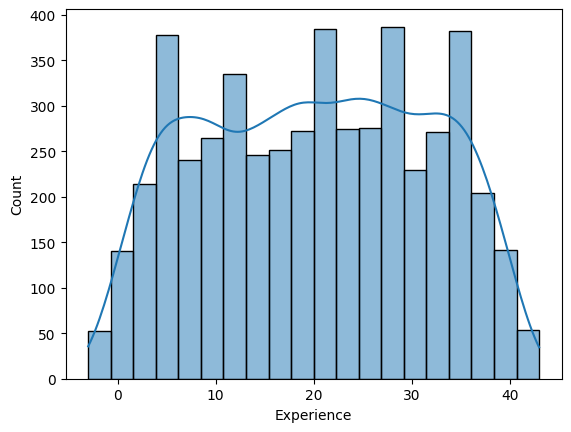

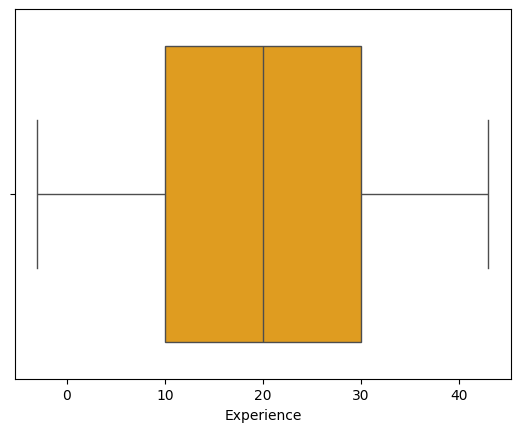

In [24]:
# Create a hisplot and analyse Experience attribute
sns.histplot(newdataFrame, x='Experience' ,kde = True)
plt.show()

# Create a boxplot and analyse Experience attribute
sns.boxplot(newdataFrame,x='Experience', color='orange')
plt.show()

Observation : There are some negative values of Experience , if we replace it with positive values the mean and std will be slightly change so keeping it same.


As per the histplot Experience variable seems to be symmetrical about mean and median.


As per the boxplot the mean and median experience of customers is equal to 20 years.


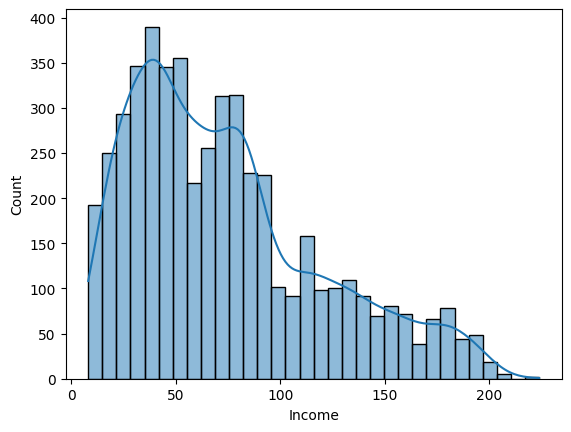

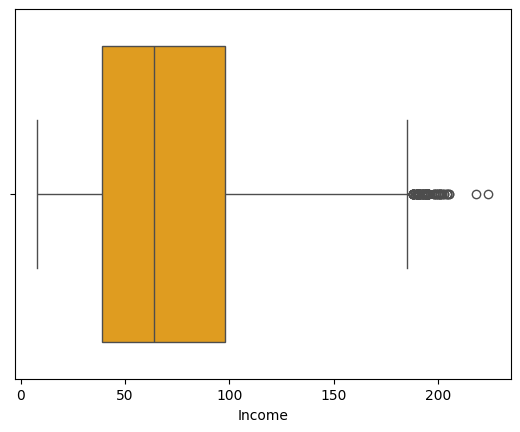

In [25]:
# Create a hisplot and analyse Income attribute
sns.histplot(newdataFrame, x='Income' ,kde = True)
plt.show()

# Create a boxplot and analyse Income attribute
sns.boxplot(newdataFrame,x='Income', color='orange')
plt.show()

Observation :
Income distribution is right skewed looking at boxplot and histplot.

As per graph there are maximum number of customr has income 50k dollars.

50% of the customers have income around less than 64k dollars.

There are some customers whose Income is above 200k dollars.



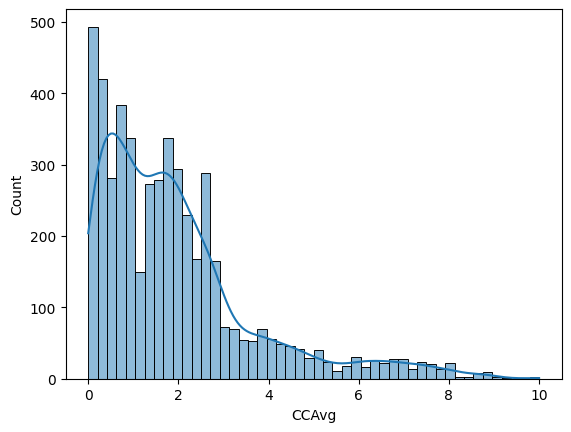

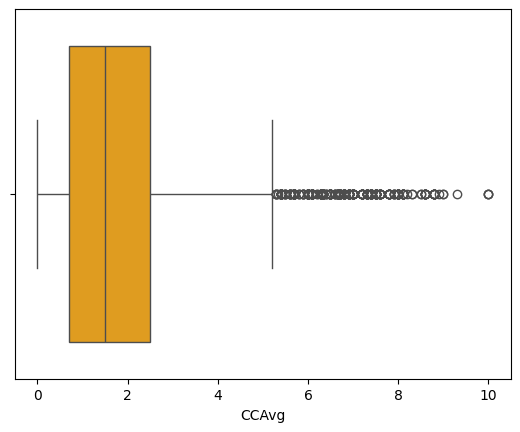

In [26]:
# Create a hisplot and analyse CCAvg attribute
sns.histplot(newdataFrame, x='CCAvg' ,kde = True)
plt.show()

# Create a boxplot and analyse CCAvg attribute
sns.boxplot(newdataFrame,x='CCAvg', color='orange')
plt.show()

Observation : CCAvg distribution is right skewed looking at boxplot and histplot.

There are many outliers present.

As per graph need to check if customers who spend more monthly are taking loan or not.


In [27]:
# check unique values of ZIPCode
newdataFrame["ZIPCode"].nunique()

467

Observation :There are 467 unique values of ZIPCode.

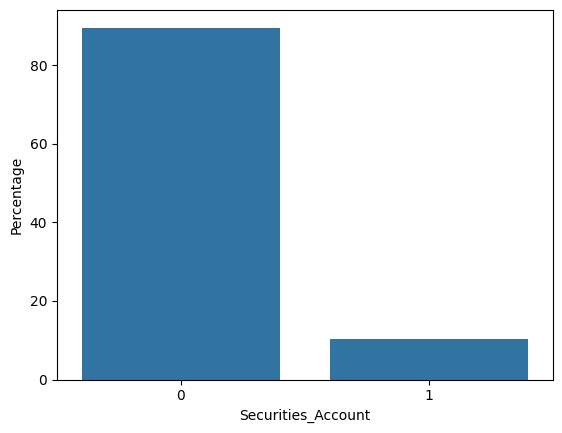

In [28]:
# Create a countplot and analyse Securities_Account attribute
sns.countplot(newdataFrame, x='Securities_Account',stat="percent")
plt.xlabel("Securities_Account")
plt.ylabel("Percentage")
plt.show()

Observation : Around 89% of the customers do not have a securities account and only around 10% customers have security account.


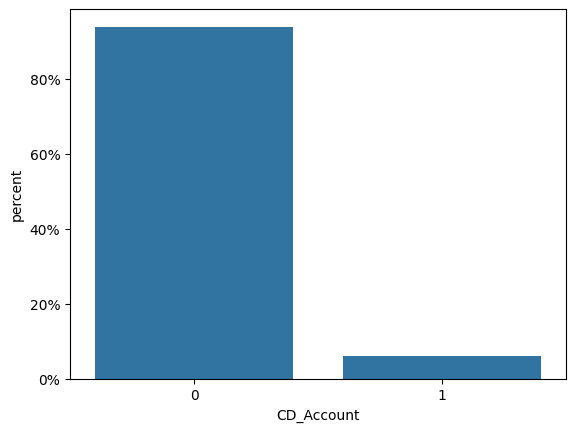

In [29]:
# Create a countplot and analyse CD_Account attribute
import matplotlib.ticker as mtick
sns.countplot(newdataFrame, x='CD_Account',stat="percent")
plt.xlabel("CD_Account")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.show()

Observation : More than 80%  of the customers do not have a certificate of deposit CD_Account with the bank.


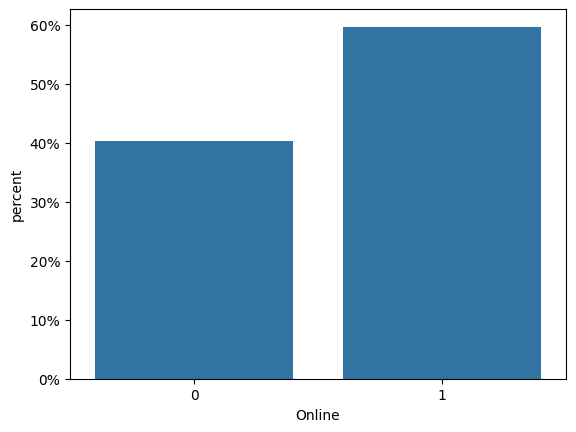

In [30]:
# Create a countplot and analyse Online attribute
sns.countplot(newdataFrame, x='Online',stat="percent")
plt.xlabel("Online")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.show()

Observation : Approx 60% of the customers use internet banking facilities.

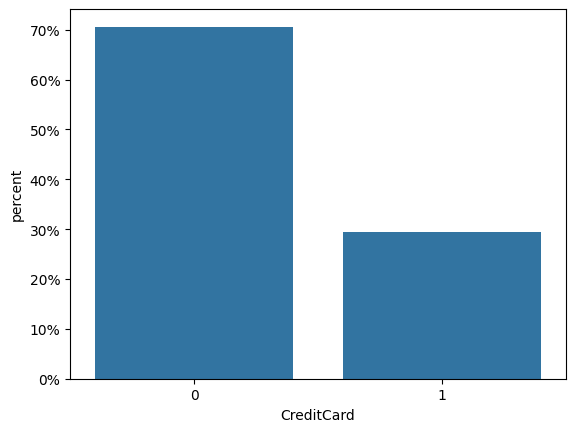

In [31]:
# Create a countplot and analyse Online attribute
sns.countplot(newdataFrame, x='CreditCard',stat="percent")
plt.xlabel("CreditCard")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.show()

Observation : Approx 70% of customers do not have a CreditCard issued by any other bank.

**Bivariate Analysis**

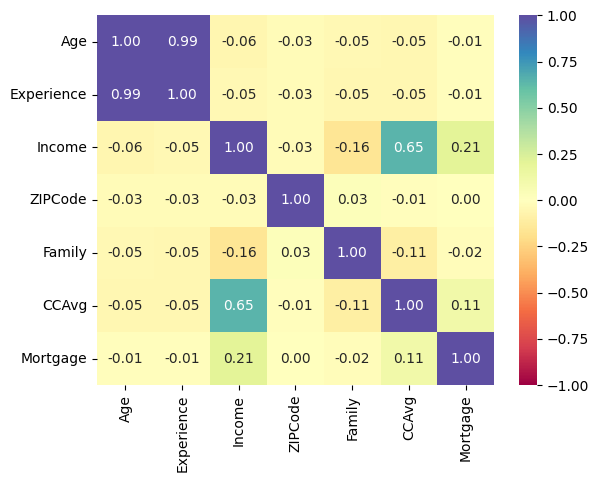

In [32]:
# Create the the heatmap of the newdataFrame
sns.heatmap(newdataFrame.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

Observation :
Age and Experience columns have a perfect correlation almost to 1 (i.e. 0.99).

Income and CCAvg have a moderate correlation so as the Income increases the spendings could also be increased.

Family has a negative correlation with Income.


**Relationship between Personal_Loan and Education**



In [35]:
# Function to plot the barplot with relevant input dataframe, independent variable and target.
def stacked_barplot(newdataFrame, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = newdataFrame[predictor].nunique()
    sorter = newdataFrame[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], newdataFrame[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(newdataFrame[predictor], newdataFrame[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [36]:
# Function to plot distributions wrt target
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()


**Relationship between Education and Personal_Loan**


Personal_Loan     0    1   All
Education                     
All            4520  480  5000
3              1296  205  1501
2              1221  182  1403
1              2003   93  2096
------------------------------------------------------------------------------------------------------------------------


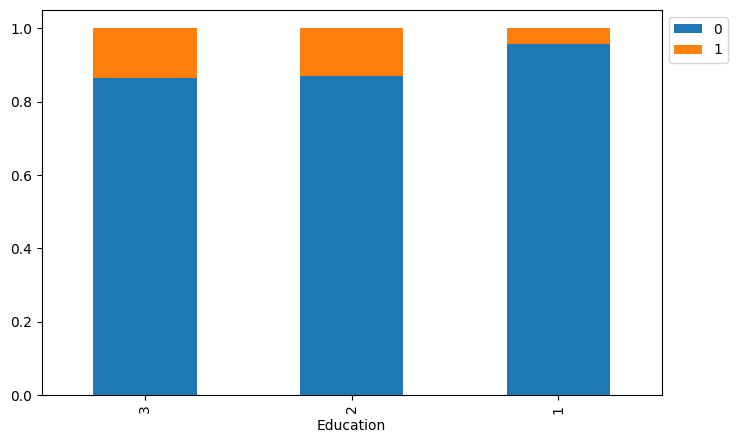

In [37]:
#Plot a barplot to show relationship between Education and Personal_Loan
stacked_barplot(newdataFrame, "Education", "Personal_Loan")

Observation :

Customers who have done Advanced/Professional studies(education level:3)  are the ones  who are taking more loan compared to other eductaion level.

Customers who are Undergraduates (education level:1) are taking least loan.

**Relationship between Family and Personal_Loan**


Personal_Loan     0    1   All
Family                        
All            4520  480  5000
4              1088  134  1222
3               877  133  1010
1              1365  107  1472
2              1190  106  1296
------------------------------------------------------------------------------------------------------------------------


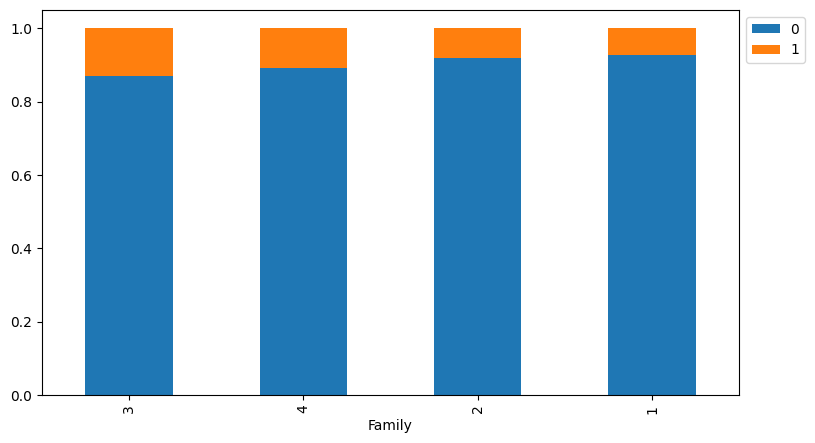

In [38]:
#Plot a barplot to show relationship between Family and Personal_Loan
stacked_barplot(newdataFrame, "Family", "Personal_Loan")

Observation :

Customers with increased family size have requiremnet of taking more Personal Loan.

Customers who have a family size of more than 2 are more likely to take a Personal Loan.

**Relationship between Securities_Account and Personal_Loan**

Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


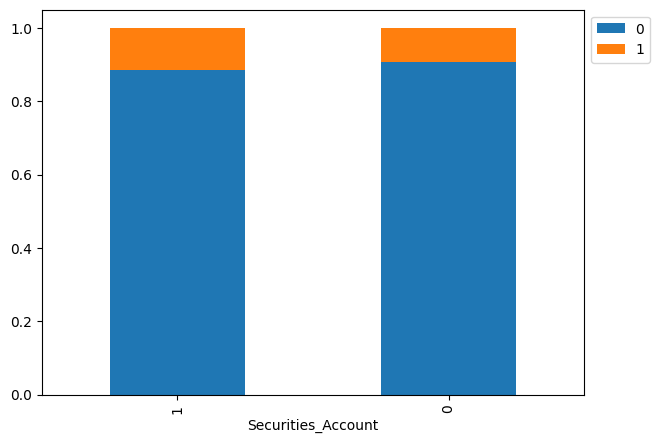

In [39]:
#Plot a barplot to show relationship between Securities_Account and Personal_Loan
stacked_barplot(newdataFrame, "Securities_Account", "Personal_Loan")

Observation : There is just a slight difference for customers who opted for and do not opted for Security Account and personal loan.


**Relationship between CD_Account and Personal_Loan**

Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


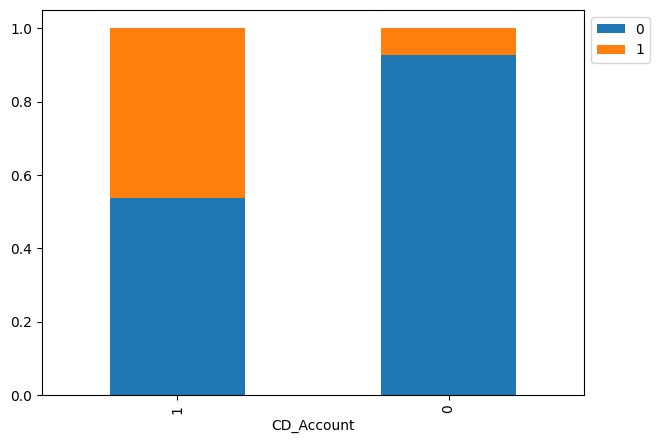

In [40]:
#Plot a barplot to show relationship between CD_Account and Personal_Loan
stacked_barplot(newdataFrame, "CD_Account", "Personal_Loan")

Observation :

Certificate of deposit account is good predictors of Personal Loan as it provides good difference between two classes.

There are almost 50 % of customers who have a CD_Account with the banks and this are the ones that have the requirement of a
Personal Loan as well.




**Relationship between Online and Personal_Loan**

Personal_Loan     0    1   All
Online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016
------------------------------------------------------------------------------------------------------------------------


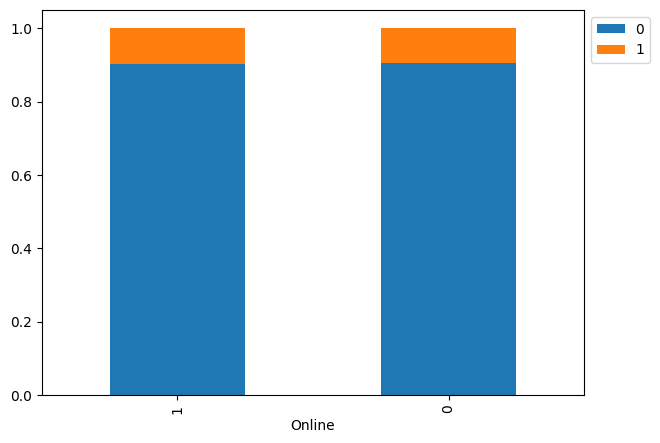

In [41]:
#Plot a barplot to show relationship between Online and Personal_Loan
stacked_barplot(newdataFrame, "Online", "Personal_Loan")

Observation : There is a very less difference between the customers who do or do not use internet banking facilities and require a Personal Loan.


**Relationship between CreditCard and Personal_Loan**

Personal_Loan     0    1   All
CreditCard                    
All            4520  480  5000
0              3193  337  3530
1              1327  143  1470
------------------------------------------------------------------------------------------------------------------------


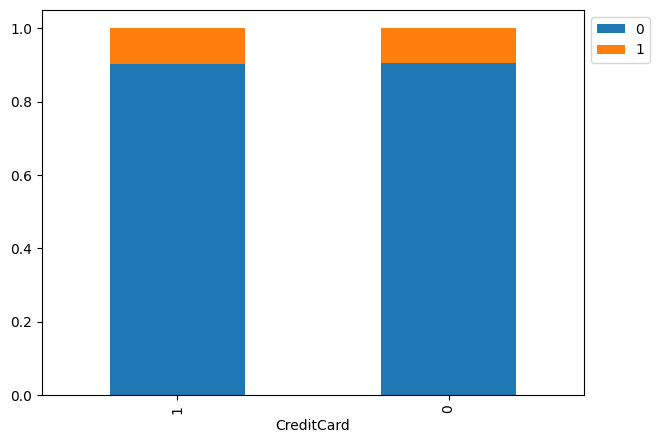

In [42]:
#Plot a barplot to show relationship between CreditCard and Personal_Loan
stacked_barplot(newdataFrame, "CreditCard", "Personal_Loan")

Observation :  There is a very less difference between the customers who do or do not use Credit Card from other banks and require a Personal Loan.

**Relationship between Age and Personal_Loan**

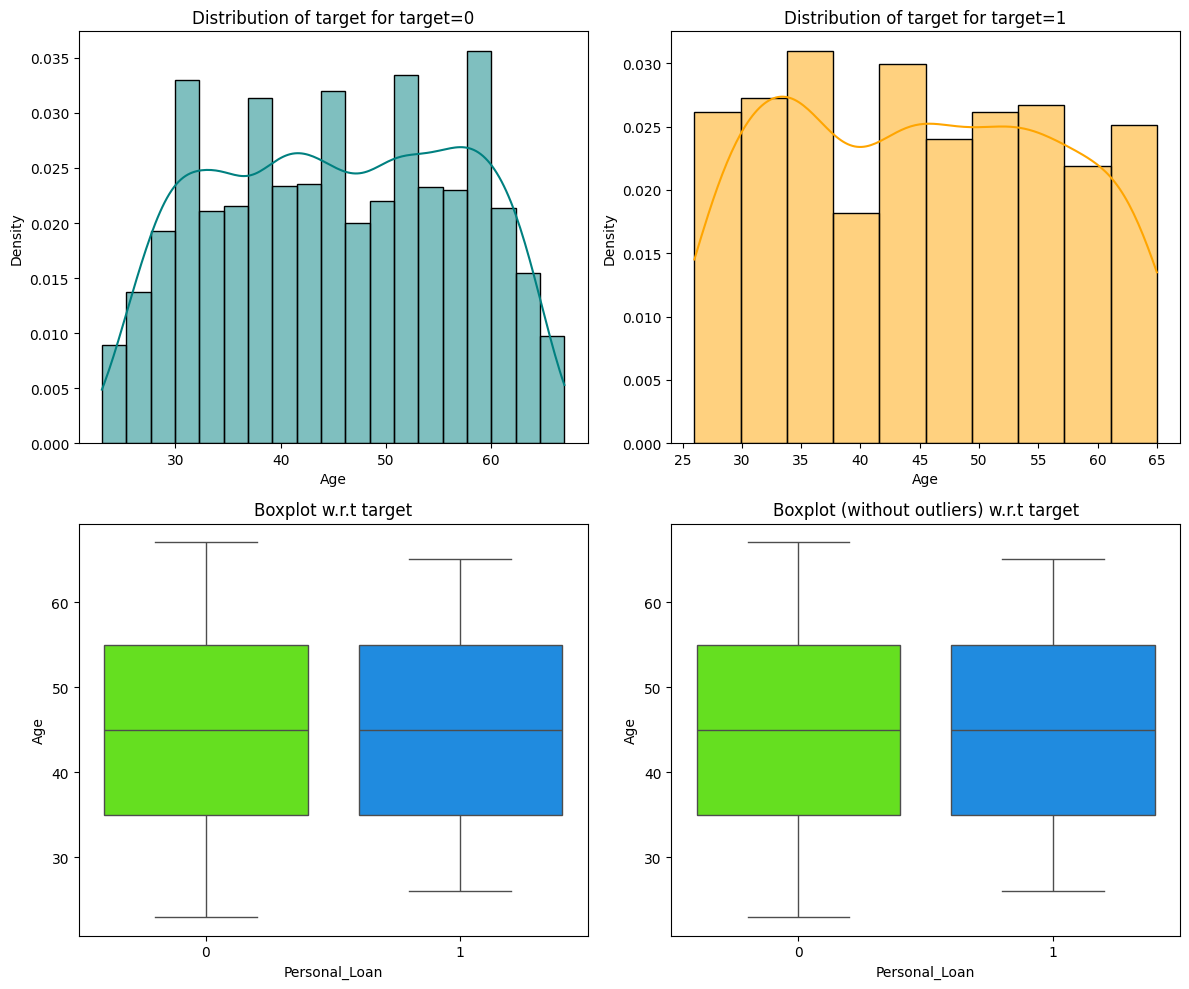

In [43]:
#Plot a graph to show relationship between Age and Personal_Loan
distribution_plot_wrt_target(newdataFrame, "Age", "Personal_Loan")


Observation :
Customer with age 45 years and below are taking more personal loan and the customers above 45 year are taking less personal loan.

**Relationship between Experience and Personal_Loan**

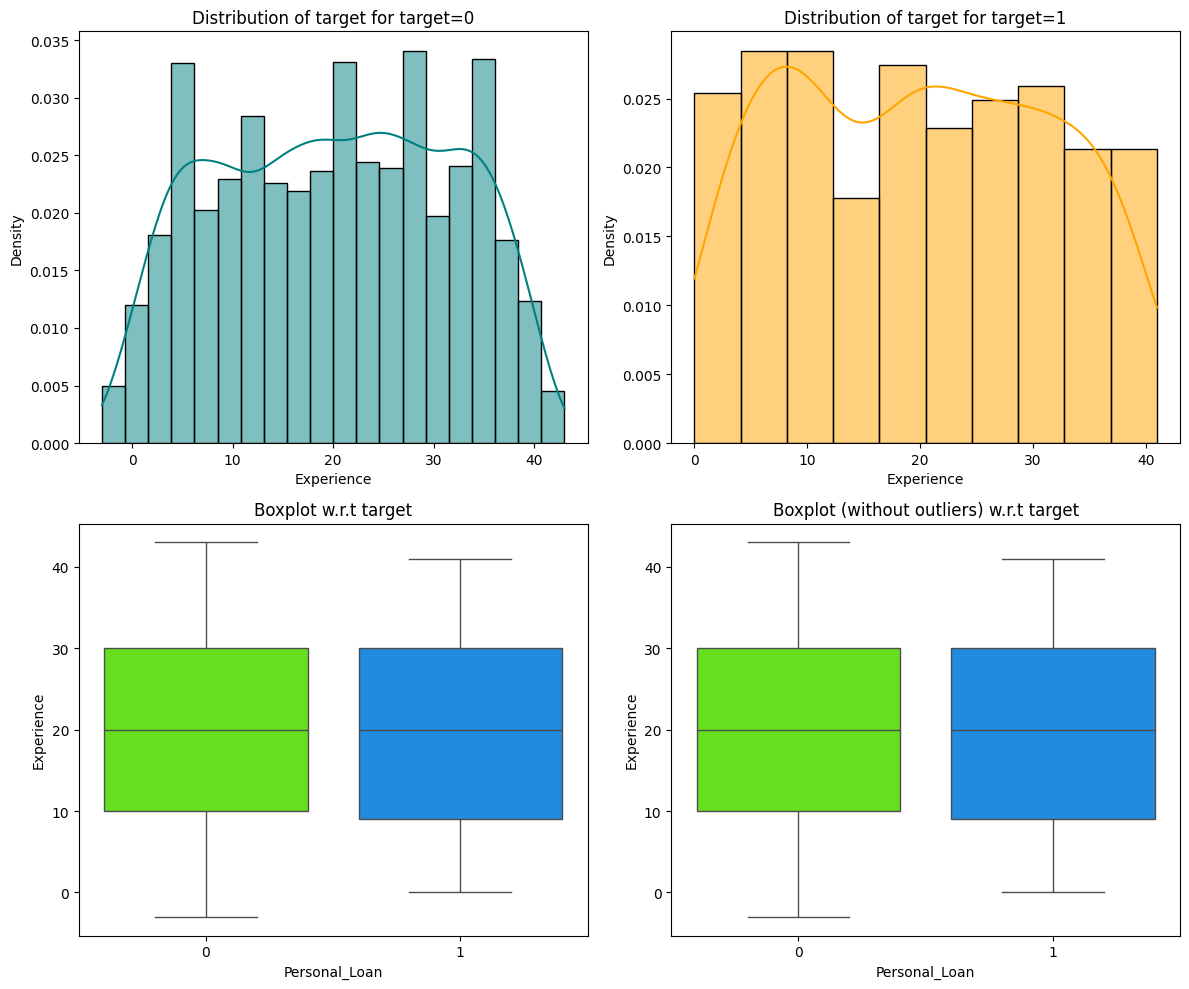

In [44]:
#Plot a graph to show relationship between Experience and Personal_Loan
distribution_plot_wrt_target(data, "Experience", "Personal_Loan")

Observation : There is no difference in experience of customers who took Personal Loan and those who did not.


**Relationship between Income and Personal_Loan**

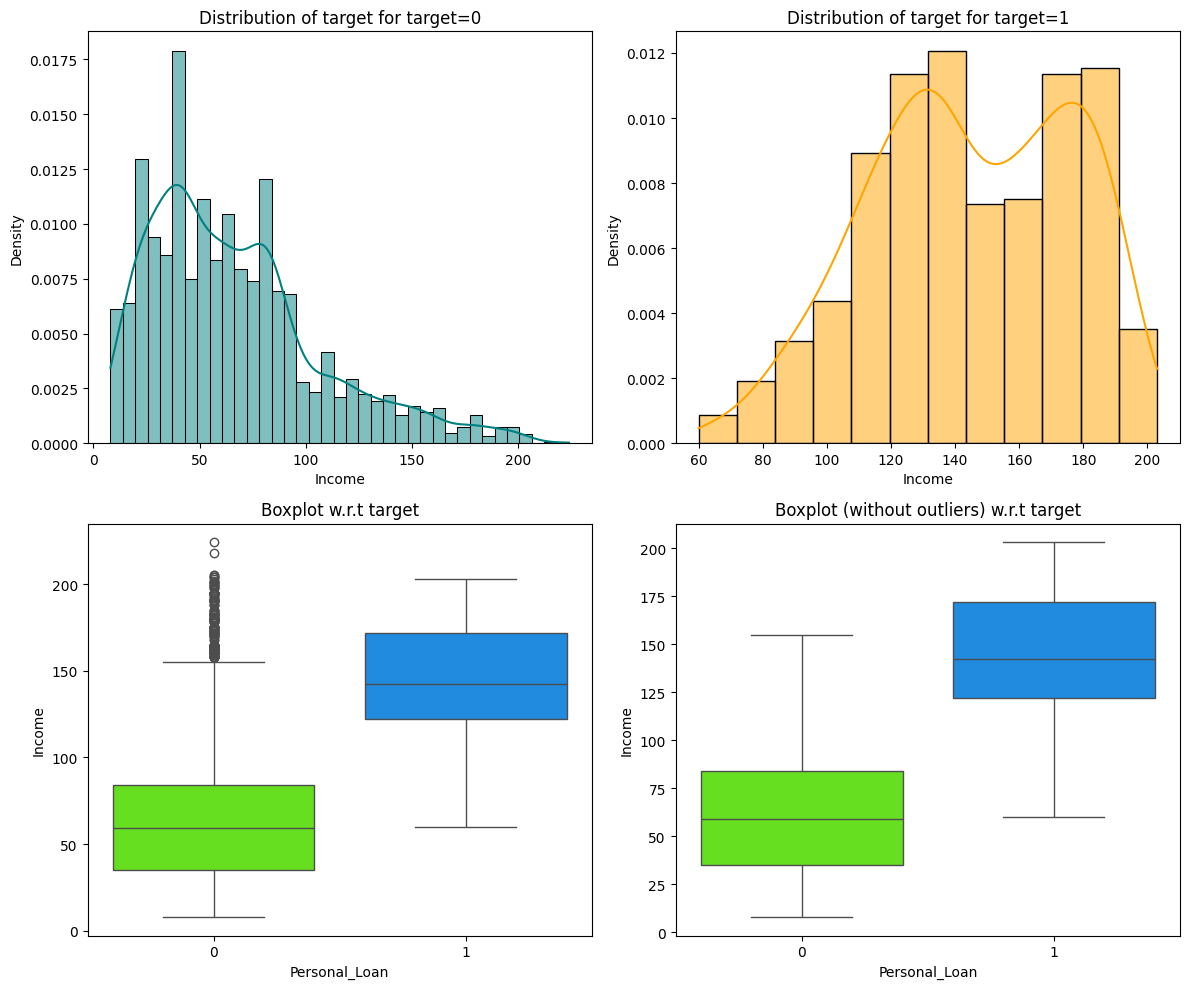

In [45]:
#Plot a graph to show relationship between Income and Personal_Loan
distribution_plot_wrt_target(data, "Income", "Personal_Loan")

Observation :
Customers who have an income higher than 90k and 100k dollars are the potential customers who will take the Personal Loan.

Income seems to be a significant predictor as it provides a good difference between two classes.

**Relationship between CCAvg and Personal_Loan**

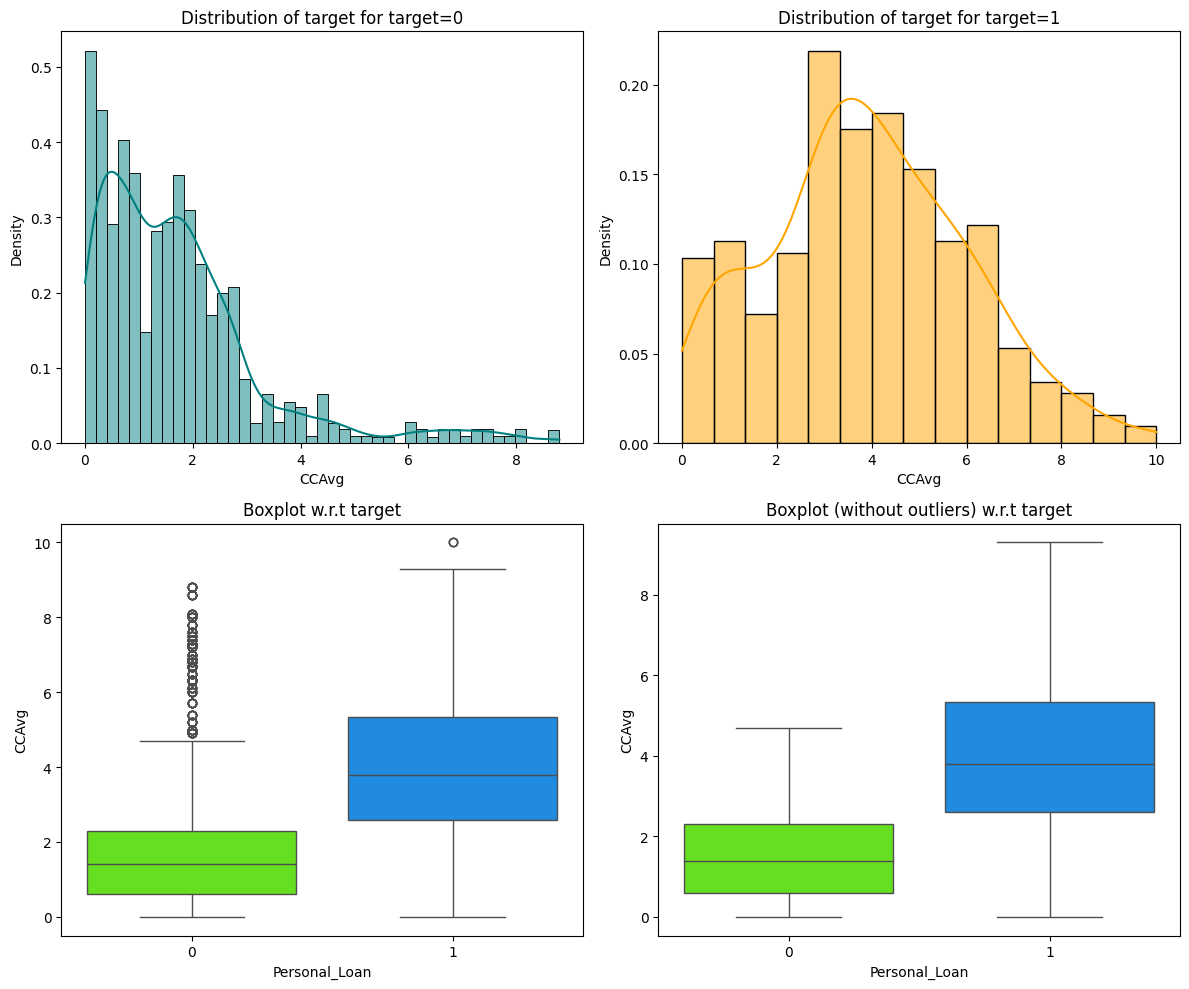

In [46]:
#Plot a graph to show relationship between CCAvg and Personal_Loan
distribution_plot_wrt_target(data, "CCAvg", "Personal_Loan")


Observation : Customers with a CCAvg of greater than 5 can be the potential customers who opt for Personal Loan.

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

**Missing value treatment**

In [47]:
# Check the missing values
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


Observation : There are no missing values so no , hence no missing value treatment is required.

**Feature engineering**

Data Transformation :  

There are Negative values of experience columns and the minimum value of the 'experience' column is -3, which  not reasonable for experience.This looks like a human error for this negative sign can be removed.


In [48]:
# Display Experience columns which have negative values.
newdataFrame[newdataFrame['Experience'] < 0].value_counts()

Age  Experience  Income  ZIPCode  Family  CCAvg  Education  Mortgage  Personal_Loan  Securities_Account  CD_Account  Online  CreditCard
23   -3          55      92704    3       2.40   2          145       0              0                   0           1       0             1
                 149     93555    2       7.20   1          0         0              0                   0           1       0             1
     -2          45      95422    4       0.60   2          0         0              0                   0           1       1             1
                 75      90291    2       1.80   2          0         0              0                   0           1       1             1
                 81      91711    2       1.80   2          0         0              0                   0           0       0             1
                 82      92152    2       1.80   2          0         0              1                   0           0       1             1
     -1          12      91605    4       1.00   1          90        0              0                   0           1       0             1
                         95064    4       1.00   1          0         0              1                   0           0       1             1
                 13      94720    4       1.00   1          84        0              0                   0           1       0             1
                 61      92374    4       2.60   1          239       0              0                   0           1       0             1
                 73      92120    4       2.60   1          0         0              0                   0           1       0             1
                 149     91709    1       6.33   1          305       0              0                   0           0       1             1
24   -3          28      90089    4       1.00   3          0         0              0                   0           0       0             1
                 41      91768    4       1.00   3          0         0              0                   0           1       0             1
     -2          50      94920    3       2.40   2          0         0              1                   0           0       0             1
                 51      90630    3       0.30   3          0         0              0                   0           1       0             1
                 80      91107    2       1.60   3          238       0              0                   0           0       0             1
                         94105    2       1.60   3          0         0              0                   0           1       0             1
                 82      91103    2       1.60   3          0         0              0                   0           1       1             1
                 118     92634    2       7.20   1          0         0              1                   0           1       0             1
                 125     92835    2       7.20   1          0         0              1                   0           0       1             1
                 135     90065    2       7.20   1          0         0              0                   0           1       0             1
                 150     94720    2       2.00   1          0         0              0                   0           1       0             1
     -1          35      94305    2       1.70   2          0         0              0                   0           0       0             1
                 38      92612    4       0.60   2          0         0              0                   0           1       0             1
                         95045    2       1.70   2          0         0              0                   0           1       0             1
                 39      94085    2       1.70   2          0         0              0                   0           0       0             1
                 75      93014    4       0.20   1       

In [49]:
# Coverting all the negative values of experience as postive sinces its not reasonable to have negative expericence so we can make it absolute value.
newdataFrame['Experience'] = abs(newdataFrame['Experience'])

In [50]:
# Covert Zip code to catagory after treating first 2 digit of zipcode
newdataFrame["ZIPCode"] = newdataFrame["ZIPCode"].astype(str)
print(
    "Number of unique values if we take first two digits of ZIPCode: ",
    newdataFrame["ZIPCode"].str[0:2].nunique(),
)
newdataFrame["ZIPCode"] = newdataFrame["ZIPCode"].str[0:2]

newdataFrame["ZIPCode"] = newdataFrame["ZIPCode"].astype("category")

Number of unique values if we take first two digits of ZIPCode:  7


**Outlier detection and treatment**

In [51]:
# outlier detection
# Get 25th percentile
Q1 = newdataFrame.quantile(0.25,numeric_only=True)

# Get 75th percentile.
Q3 = newdataFrame.quantile(0.75,numeric_only=True)

# Inter Quantile Range (75th perentile - 25th percentile)
IQR = Q3 - Q1

 # Finding lower and upper bounds for all values. All values outside these bounds are outliers
lower = (Q1 - 1.5 * IQR)
upper = Q3 + 1.5 * IQR

(
(newdataFrame.select_dtypes(include=["float64", "int64"]) < lower)
| (newdataFrame.select_dtypes(include=["float64", "int64"]) > upper)
).sum() / len(data) * 100


,0
Age,0.00
Experience,0.00
Income,1.92
Family,0.00
CCAvg,6.48
Mortgage,5.82


Observation : As per the table above the outlier are present in real case scenario like Income, Mortage value , CCAvg attributes so we would want our model to learn the underlying pattern for such customers hence we will not treat the outlier.

**Preparing data for modeling**

In [52]:
# dropping Experience as it is perfectly correlated with Age
X = newdataFrame.drop(["Personal_Loan", "Experience"], axis=1)
Y = newdataFrame["Personal_Loan"]
X = pd.get_dummies(X, columns=["ZIPCode", "Education"], drop_first=True)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=1)


In [54]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 17)
Shape of test set :  (1500, 17)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


Observation : As per training set about 90.5% of observations belongs to  0 (Not opted for Loan) and 9.45% observations belongs to class 1 (Opted for loan).

As per test set about 90.0% of observations belongs to  0 (Not opted for Loan) and 9.93% observations belongs to class 1 (Opted for loan).


## Model Building

### Model Evaluation Criterion

**Model predicting expected outcome :**

* Customer have taken the loan and model also predicted that customer had taken loan (TP)
* Customer have not taken the loan and model also predicted that customer had not taken loan (TN)

**Model can make wrong predictions as:**

*  Model predicting a customer will get a loan but in reality, the customer does not get a loan (FP) - Loss of resources
* Model predicting a customer will not get loan but in reality, the customer gets loan (FN) - Loss of opportunity


**Which case is more important?**

* If we predict that a customer will not get a loan but in reality, the customer would get a loan, then the bank might miss out on loan customers.(FN scenario looks to be more important case)
* If we predict that a customer will get a loan but in reality, the model predicted that customer does not get a loan, then the bank will lose some money on marketing campaigns.

**How to reduce the losses?**

To reduce losses we need to minimize false negatives and the banks would want recall to be maximized , Hence we should increase recall and minimize FN.






Build Decision Tree Model

In [55]:
#Building a model using the DecisionTreeClassifier function, using default 'gini' criteria to split.
model = DecisionTreeClassifier(criterion="gini", random_state=1)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [56]:
#Checking Score Decision Tree
print("Accuracy on training set : ",model.score(X_train, y_train))
print("Accuracy on test set : ",model.score(X_test, y_test))

Accuracy on training set :  1.0
Accuracy on test set :  0.986


Observation : The ratio accuracy on traing (100%) and test sets showing imbalanced dataset , so its not good to evaluate accuracy here.


Creating functions we can use to calculate different metrics and confusion matrix.

The model_performance_classification_sklearn_with_threshold function will be used to check the performance of models.

The confusion_matrix_sklearn_with_threshold function will be used to plot confusion matrix.


In [57]:
# Defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # Predicting using the independent variables
    pred = model.predict(predictors)

    # Compute Accuracy
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [58]:
# Defining a function to plot the confusion_matrix of a classification model built using sklearn
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

Checking model performance on training set

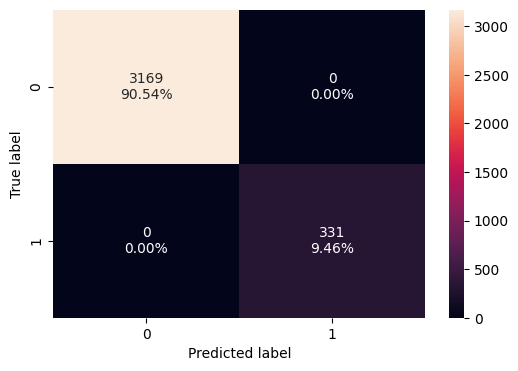

In [59]:
# Checking confusion matrix on traning set
confusion_matrix_sklearn(model, X_train, y_train)

In [60]:
# Verifying the model performance on training data
decision_tree_perf_train = model_performance_classification_sklearn(
model, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


Observation :
As per the model, performance on training data accuracy,recall,precision and F1 score have 0 errors, each sample has performed very well on training set which
could mean there is overfitting.


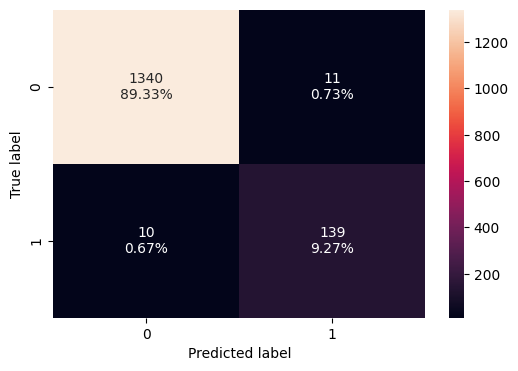

In [61]:
# Checking confusion matrix on test set
confusion_matrix_sklearn(model, X_test, y_test)

In [62]:
# Verifying the model performance on test set
decision_tree_perf_test = model_performance_classification_sklearn(
    model, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.986,0.932886,0.926667,0.929766


Observation : On test set Accuracy is 0.98 , recall is 0.93 ,precision is 0.92 and F1 score is 0.92 , we will further check if this can be improved.

## Model Performance Improvement

Recreating the Decision Tree with class_weights as hyperparameter which could give more clarity on imbalanced datasets.

In [63]:
#Building a model using the DecisionTreeClassifier function, using class_weight="balanced"
model = DecisionTreeClassifier(random_state=1, class_weight="balanced")
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

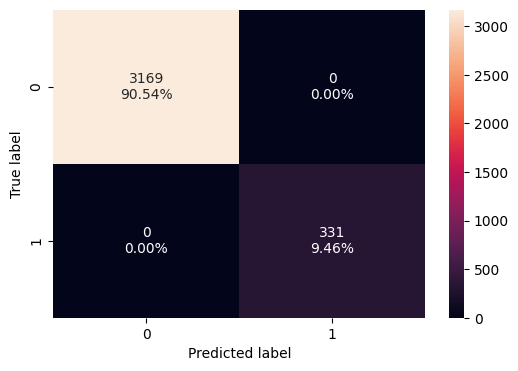

In [64]:
# Checking confusion matrix on traning set
confusion_matrix_sklearn(model, X_train, y_train)

In [65]:
# Verifying the model performance on training set
decision_tree_perf_train = model_performance_classification_sklearn(
    model, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


Observation : With class weight using balanced still model perfectly fits the training data which could mean there is overfitting.


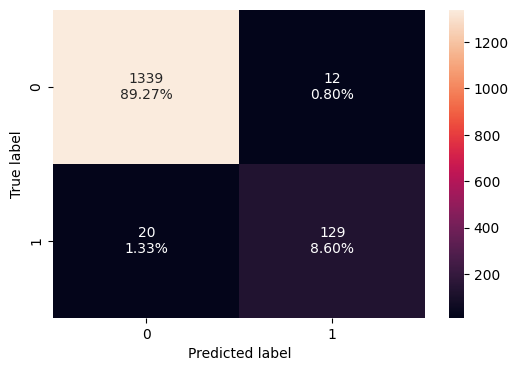

In [66]:
# Checking confusion matrix on test set
confusion_matrix_sklearn(model, X_test, y_test)

In [67]:
# Verifying the model performance on test set
decision_tree_perf_test = model_performance_classification_sklearn(
    model, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.978667,0.865772,0.914894,0.889655


Observation : There is a huge difference in performance of model on training set and test set, which suggests that the model is overfiiting.


Decision Tree (Pre-Pruning)

In [68]:
# Define a decisionTreeClassifier
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "class_weight": [None, "balanced"],
    "max_depth": np.arange(2, 4, 6), # [2, 4, 6]
    "max_leaf_nodes": [50, 75, 150, 250],
    "min_samples_split": [10, 30, 50, 70],
}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Define the Grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(2),
                       max_leaf_nodes=50, min_samples_split=10, random_state=1)

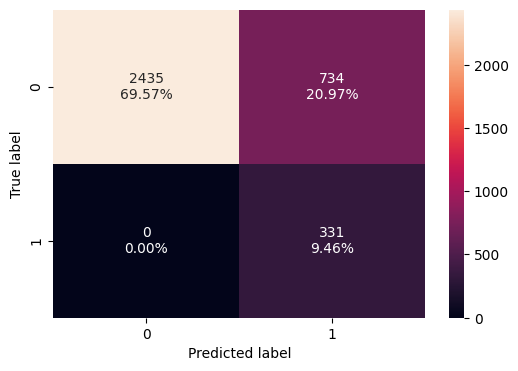

In [69]:
# Checking confusion matrix on traning set
confusion_matrix_sklearn(estimator, X_train, y_train)

In [70]:
# Verifying the model performance on trainig set
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    estimator, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.790286,1.0,0.310798,0.474212


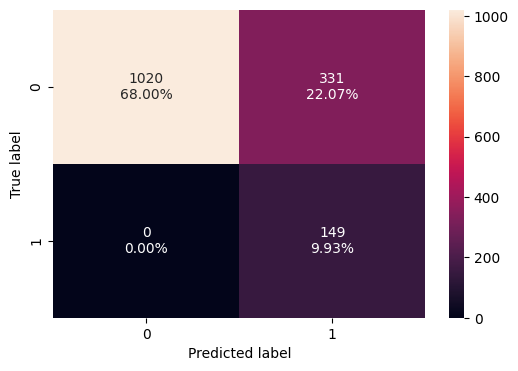

In [71]:
# Checking confusion matrix on test set
confusion_matrix_sklearn(estimator, X_test, y_test)

In [72]:
# Verifying the model performance on test set
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    estimator, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.779333,1.0,0.310417,0.473768


Observation :
After tuning the training and test set the model is giving a generalized result now, the Recall scores on both the train and test data are 1.0 and the F1 scores on both are around 0.47, which shows that the model is able to generalize well on unseen data.


In [73]:
# List all the training columns
feature_names = list(X_train.columns)
# Retrieveing the importance scores from trained model
importances = estimator.feature_importances_
# sort the importance scores using numpy
indices = np.argsort(importances)

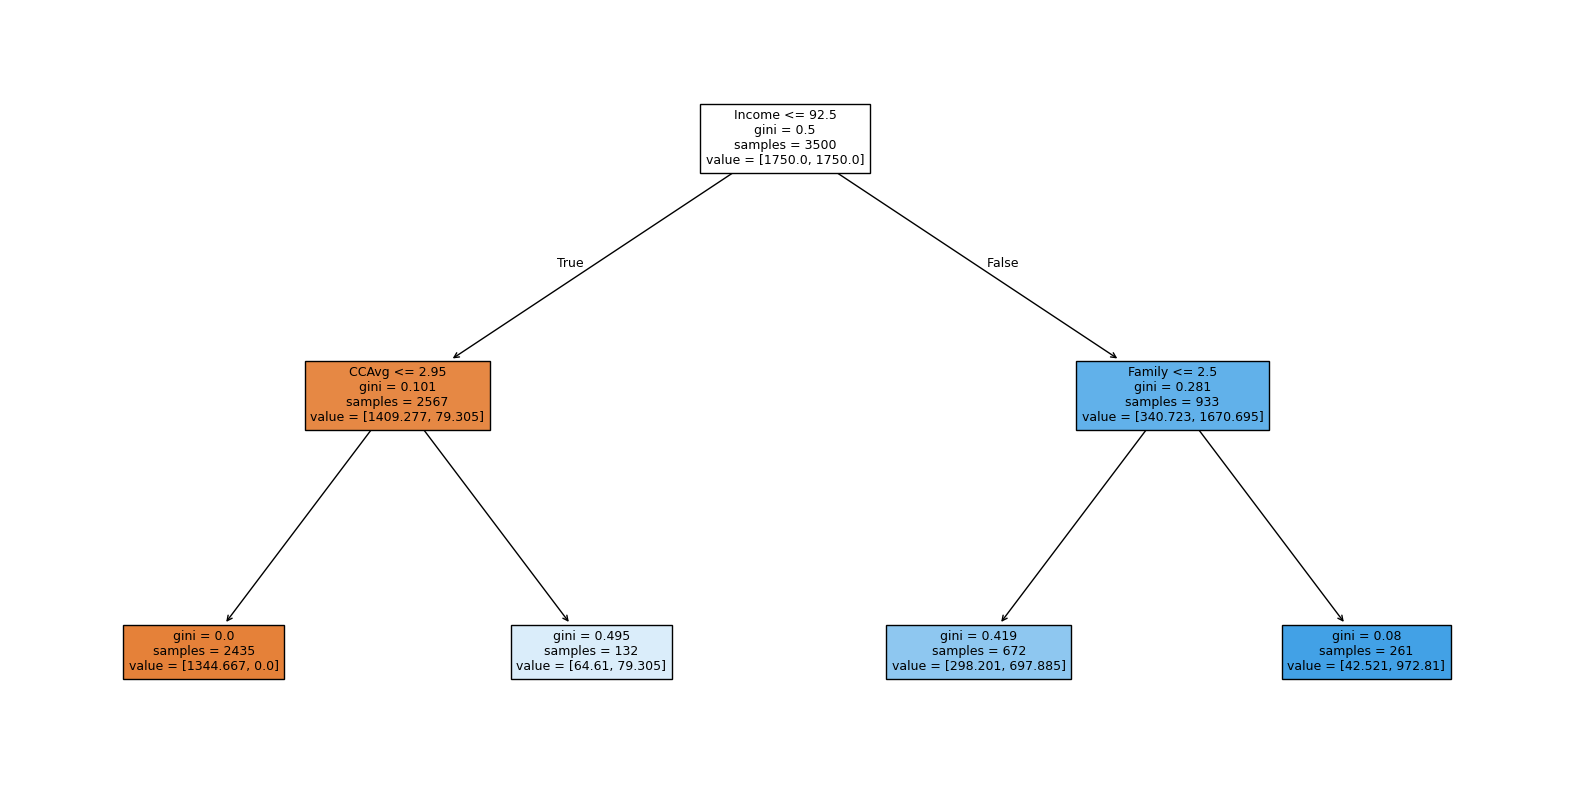

In [74]:
# Plot the decesion tree
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [75]:
# Text report showing the rules of a decision tree -
print(tree.export_text(estimator, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [64.61, 79.31] class: 1
|--- Income >  92.50
|   |--- Family <= 2.50
|   |   |--- weights: [298.20, 697.89] class: 1
|   |--- Family >  2.50
|   |   |--- weights: [42.52, 972.81] class: 1



Observation :

For Income is less or equal to 92500 dollars per year, if the average credit card spending is less or equal to 2950 dollars per month, then the customer is most likely not get a loan. However, if the average credit card spending is more than 2950 dollars per month, then the customer is most likely to get a loan.

For Income more than 92500 dollars per year and irrespective of their education levels, they are most likely to get a loan.

In [76]:
# Get the importance of each input feature after a machine learning model has been trained
importances = estimator.feature_importances_
importances

array([0.        , 0.87652937, 0.05653065, 0.06693998, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        ])

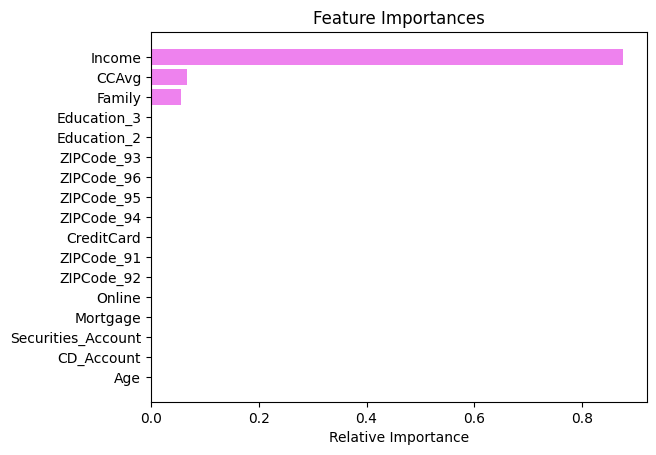

In [77]:
importances = estimator.feature_importances_
indices = np.argsort(importances)
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Observation : In the pre-tuned decision tree, Income, Education, & CCAvg are most important features.

(Note : While creating feature_importances_ graph there was observation that graph was not clear and jumbled up due to large number of ZIPCodes present in data so have done feature engineering data transformation of zipcode modified zip code to take first two digits of it in above steps )


Decision Tree (Post-Pruning)

In [78]:
# Now performing post pruning on decision Tree with class_weight & calculate cost complexity pruning path
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [79]:
# Create a pandas dataframe from the cost complexity pruning path object
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-7.759588e-16
1,3.853725e-19,-7.755734e-16
2,4.729571e-19,-7.751004e-16
3,5.255079e-19,-7.745749e-16
4,5.255079e-19,-7.740494e-16
5,7.707449e-19,-7.732787e-16
6,1.051016e-18,-7.722277e-16
7,1.576524e-18,-7.706511e-16
8,1.257806e-17,-7.580731e-16
9,1.524700e-04,3.049400e-04


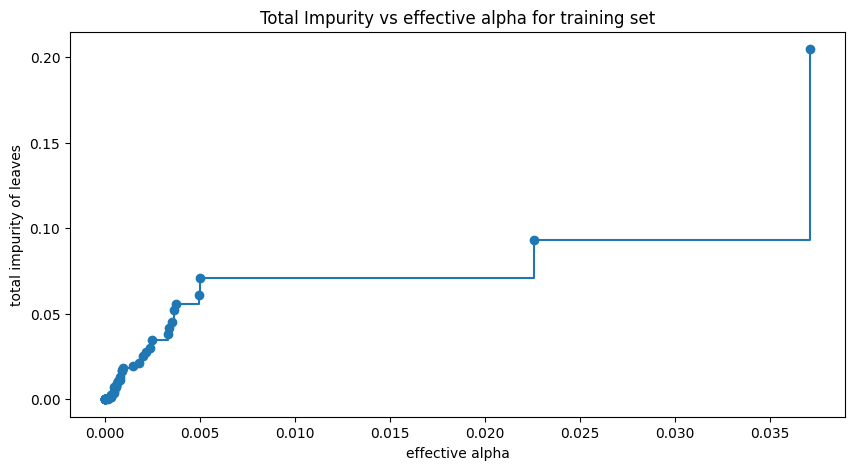

In [80]:
# Plotting graph to checkk alpha vs total impurity
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [81]:
# Train Decision tree using the effective alphas.
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.2953792759992314


Observation : After training the decision tree using effective alphas , the number of node in last tree is 1 and has ccp_alpha : 0.2953792759992314 that prunes the whole tree, leaving the tree, clfs[-1], with one node.

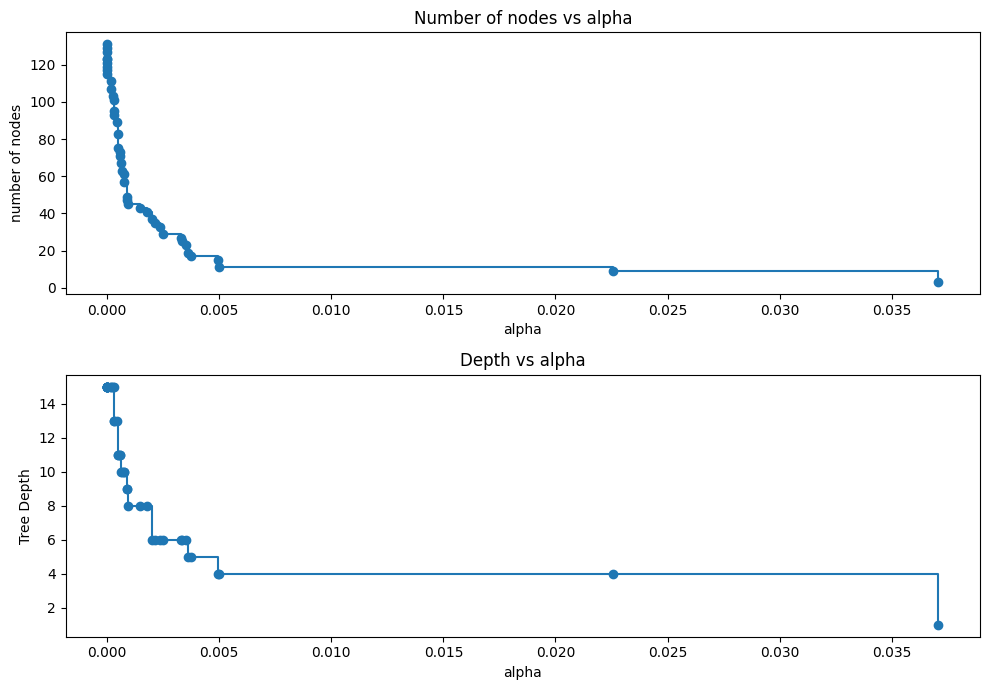

In [82]:
# we remove the last element in clfs and ccp_alphas, because it is the trivial tree with only one node.
# AS the number of nodes and tree depth decreases as alpha increases.
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Calculate the number of nodes and the depth of the tree for each classifier in clfs
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

# Create a figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot number of nodes vs alpha on the first subplot
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")

# Plot depth of tree vs alpha on the second subplot
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("Tree Depth")
ax[1].set_title("Depth vs alpha")

# Adjust layout to prevent overlap and ensure everything fits within the figure area
fig.tight_layout()

Observation : The graphs clearly show that number of nodes and tree depth decreases as alpha increases.

In [83]:
# Get the Recall value for every pruned tree in the training set and append it to a list
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [84]:
# Get the Recall value for every pruned tree in the testing set and append it to a list
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [85]:
# Calculate the accuracy scores of training and test sets using each classifier in the list of classifiers
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]
#print ('train_scores' ,train_scores)
#print ('test_scores' ,test_scores)

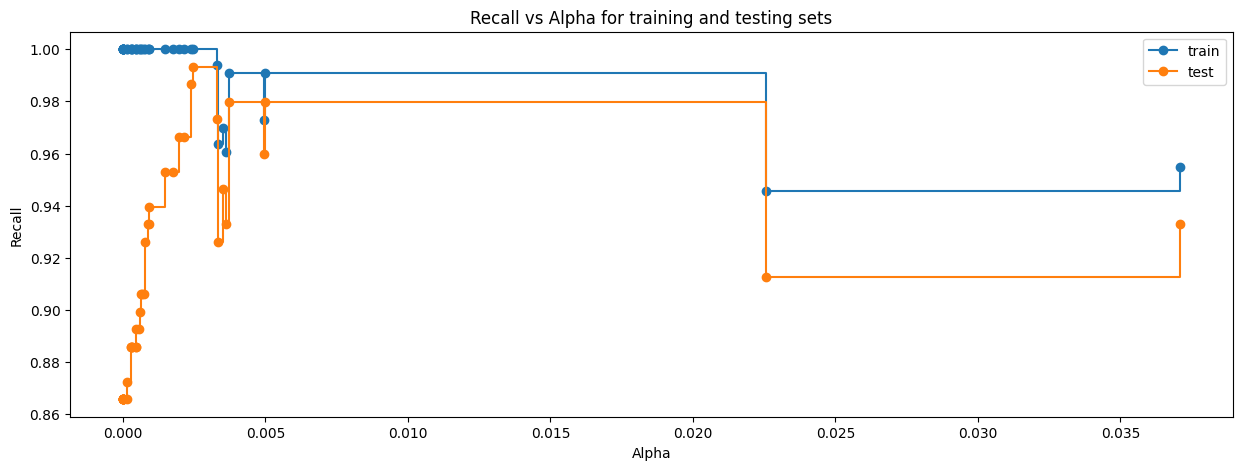

In [86]:
# Plot recall scores for the training & testing sets against alpha values
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("Alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs Alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [87]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0024726598786422157),
                       class_weight='balanced', random_state=1)


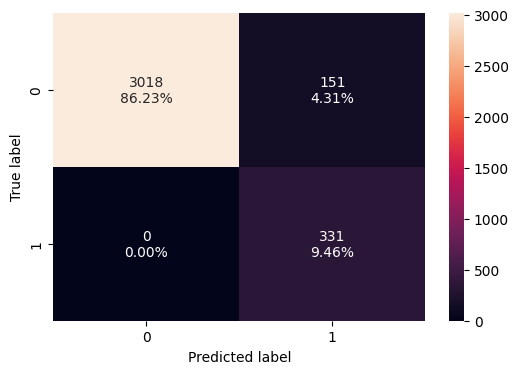

In [88]:
# Creating confusion matrix on train data
confusion_matrix_sklearn(best_model, X_train, y_train)

In [89]:
# Verifying the model performance on train set
decision_tree_post_perf_train = model_performance_classification_sklearn(
    best_model, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.956857,1.0,0.686722,0.814268


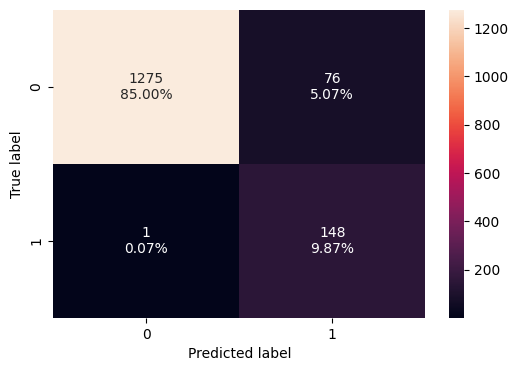

In [90]:
# Creating confusion matrix on test data
confusion_matrix_sklearn(best_model, X_test, y_test)

In [91]:
# Verifying the model performance on test set
decision_tree_post_test = model_performance_classification_sklearn(
    best_model, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.948667,0.993289,0.660714,0.793566


Observation : The model is giving a generalized result in post pruned tree also and the recall scores on both the train and test data are coming to be around 0.99 - 1.0 which shows that the model is able to generalize well on unseen data.

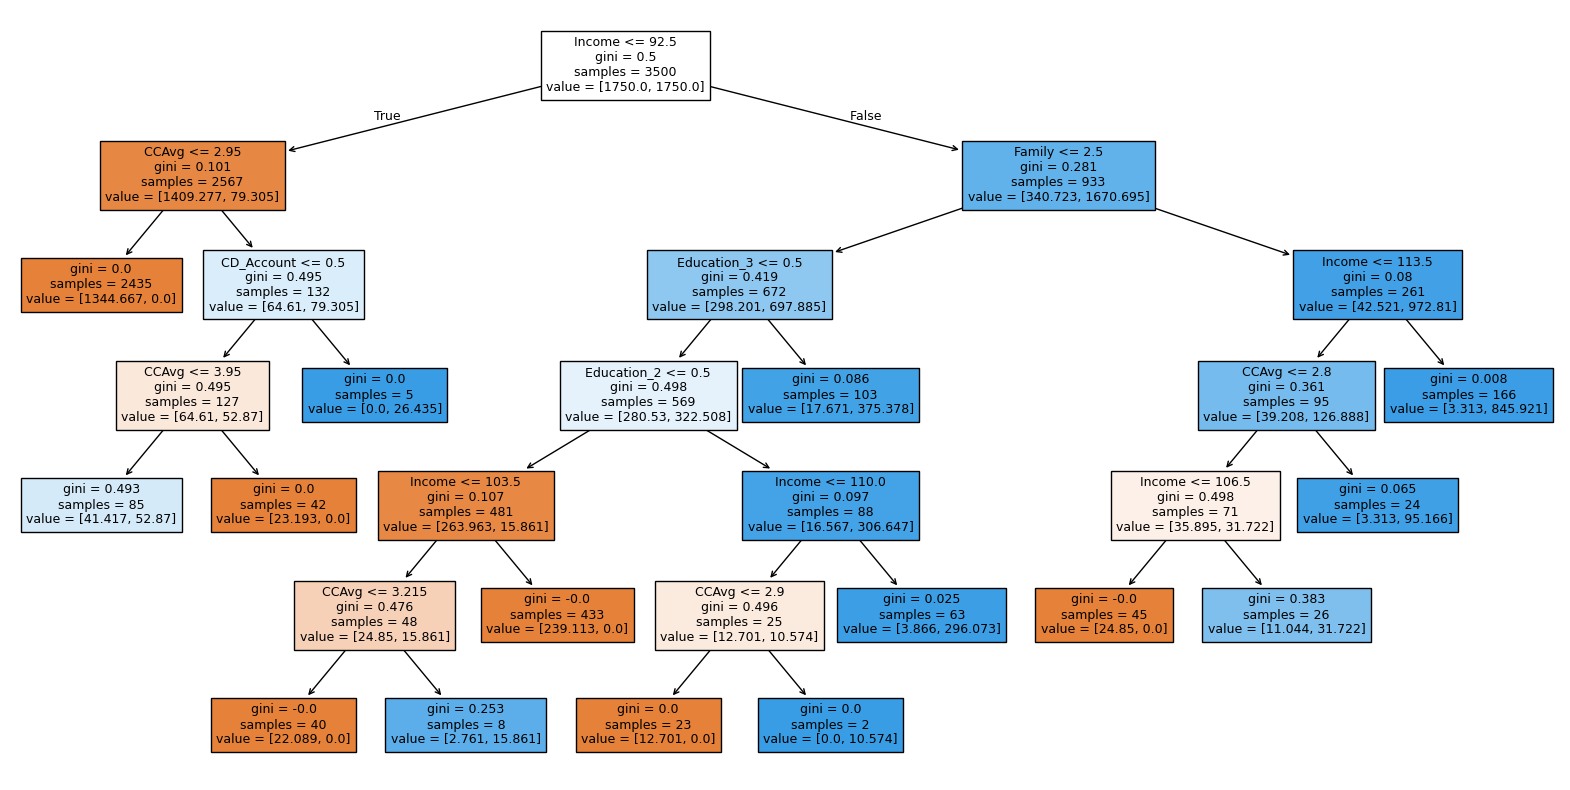

In [93]:
# Plotting a Decision tree
# Set the figure size for the plot
plt.figure(figsize=(20, 10))

# Plot the decision tree using the plot_tree function
out = tree.plot_tree(
    best_model,
    feature_names=feature_names,  # Names of features
    filled=True,  # Fill the nodes with color
    fontsize=9,  # Font size for text
    node_ids=False,  # Do not display node IDs
    class_names=None,  # Names of the classes (if applicable)
)

# Customize the appearance of arrows in the plot
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")  # Set the edge color of arrows to black
        arrow.set_linewidth(1)  # Set the width of arrows to 1

# Display the plot
plt.show()

In [482]:
# Text report showing the rules of a decision tree
print(tree.export_text(best_model, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- weights: [41.42, 52.87] class: 1
|   |   |   |--- CCAvg >  3.95
|   |   |   |   |--- weights: [23.19, 0.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [0.00, 26.44] class: 1
|--- Income >  92.50
|   |--- Family <= 2.50
|   |   |--- Education_3 <= 0.50
|   |   |   |--- Education_2 <= 0.50
|   |   |   |   |--- Income <= 103.50
|   |   |   |   |   |--- CCAvg <= 3.21
|   |   |   |   |   |   |--- weights: [22.09, 0.00] class: 0
|   |   |   |   |   |--- CCAvg >  3.21
|   |   |   |   |   |   |--- weights: [2.76, 15.86] class: 1
|   |   |   |   |--- Income >  103.50
|   |   |   |   |   |--- weights: [239.11, 0.00] class: 0
|   |   |   |--- Education_2 >  0.50
|   |   |   |   |--- Income <= 110.00
|   |   |   |   |   |--- CCAvg <= 2.90
|   |   |   |   |   |   |--- weights: [12

Observation : Post prune tree has validated the observation which we have got from pre pruned tree and even now post prune tree is giving more granular predictions.

In [94]:
# Calculate the feature importances from the best performing decision tree model
importances = best_model.feature_importances_
indices = np.argsort(importances)

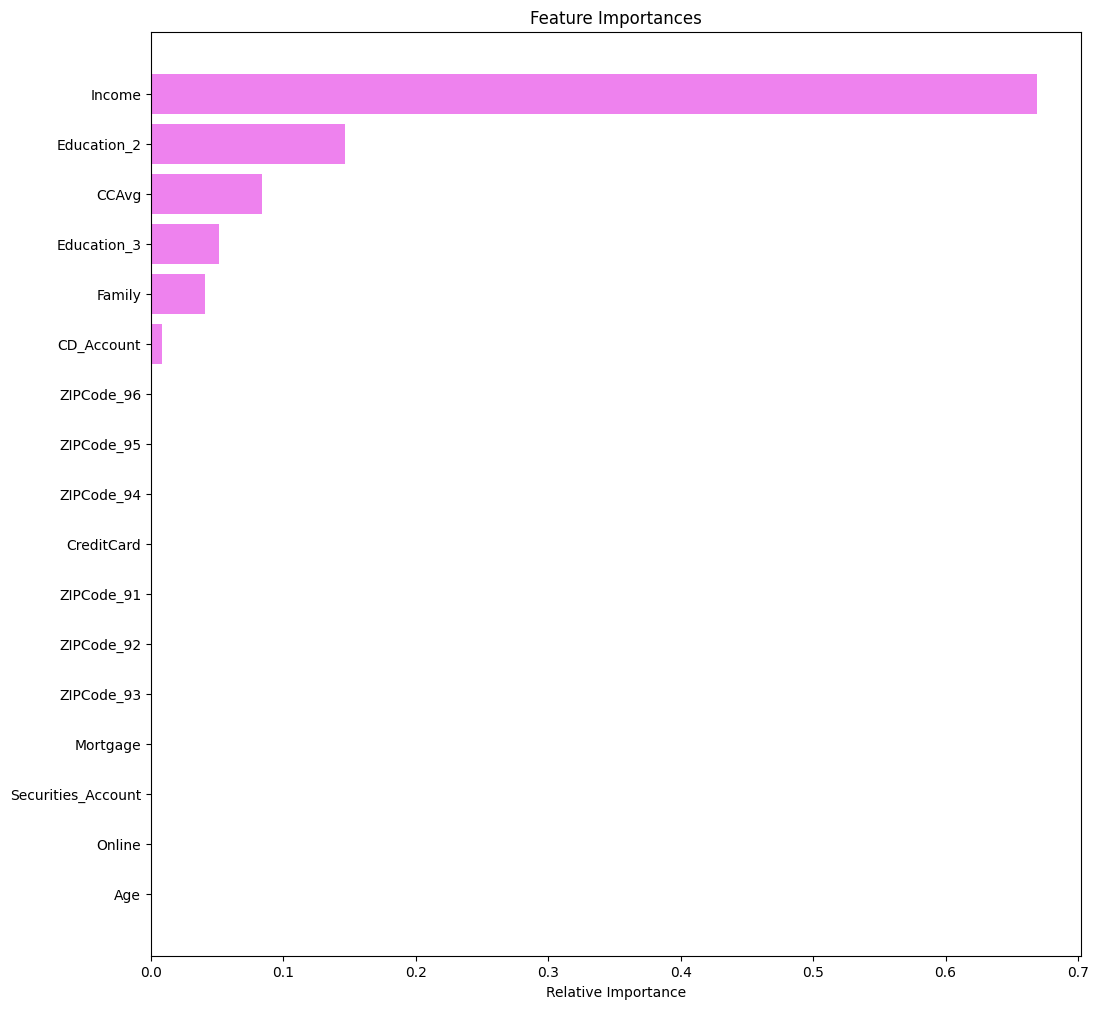

In [95]:
# Plot the Feature Importance
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Observation : Income, Education, CCAvg, Family and CD_Account are the most important features for the post-pruned tree


## Model Performance Comparison and Final Model Selection

In [96]:
# Training model performance comparison
models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.790286,0.956857
Recall,1.0,1.000000,1.000000
Precision,1.0,0.310798,0.686722
F1,1.0,0.474212,0.814268


Observation : On Comparing Training model performance its giving recall as 1 for both pre-pruned and post-pruned model and Precision is less in pre-pruned as compared to post-pruned model.

In [97]:
# Testing Performance Comparison
models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.978667,0.779333,0.948667
Recall,0.865772,1.000000,0.993289
Precision,0.914894,0.310417,0.660714
F1,0.889655,0.473768,0.793566


Observation : On Comparing Testing model performance its giving recall as 1 for pre-pruned and 0.99 for post-pruned model which is almost to 1 and Precision is less in pre-pruned as compared to post-pruned model.


So we can conclude that both pre-pruning and post-pruning models giving equally high recall scores on both training and test sets
However, we will choose the POST-Pruned tree as the best model since it is giving a high precision score on the train and test sets than the pre-pruned tree.

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

Based on the post-pruned decision tree model my key findings of Personal_Loan_Campaign Project with respect to Income, Family, Education, CCAvg, and CD_Account includes below points :


The top 5 features in predicting whether a customer will take a loan or not are Income, Family, Education, CCAvg(Credit Card Average Spending), and CD_Account.

* Income and CCAvg :


  Customers with an income less than or equal to 92500 dollars per year and average credit card spending per month is less than or equal to 2950 dollars are predicted to not accept the personal loan.

  Customers with an income less than or equal 92500 dollars with a CCAvg greater than 2950 dollars , who also do not have a CD_Account that is less than 0.50 and if their CCAvg is less than or equal to 3950 dollars, they are predicted to accept the personal loan.

  Customers with an income less than or equal 92500 dollars with a CD_Account > 0.50 are also predicted to accept the personal loan regardless of their CCAvg. This indicates that the presence of a CD account is a significant indicator of personal loan acceptance for lower income customers.


* Education and Family Size :        
  
  Customers with an income greater than 92500 dollars and education level less than or equal to 1.50 , if their family size is less than or equal to 2.50 and their income is less than or equal to 103,500 dollars they are predicted to not accept the personal loan.

  Customers with an income greater than 92500 dollars and education level greater than 1.50 and if their income is less than or equal to 116500 dollars and their CCAvg is greater than 28500 dollars are predicted to accept the personal loan.

**Recommendations:**

  Customers who have income above 116k dollars and a family of more than 2, such customers have higher chances of taking personal loans, this customers should be the target customers for bank.


  Customers whose education level is higher than undergraduate have a higher chance of taking a personal loan , this customers should be the target customers for bank.


  Family has a positive correlation with the personal loan, as the size of the family increases the chances of taking loans increases, this customers should be the target customers for bank.

  There are almost 50 % of customers who have a CD_Account with the banks and this are the ones that have the requirement of a
  Personal Loan as well, this should be target customer for bank.







___